In [22]:
## Step 1 - Use Only pop

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

pop = pd.read_csv(r"C:\Users\teren\OneDrive\Documents\Education\05._SpringBoard\03._Capstone Project\EV_Project\05. Modeling\electric_vehicles_spec_2025_Post_EDA.csv")

pop.columns = pop.columns.str.lower().str.strip().str.replace(" ", "_")

In [23]:
# 1. LOAD DATA & INITIAL SUMMARY
# ---------------------------------------------------------
# Using the 'pop' DataFrame loaded in the previous step as per "Use Only pop" instruction.

print(f"Initial Data Shape: {pop.shape}")
print("\nFirst 5 rows of dataset:")
print(pop.head())

Initial Data Shape: (472, 22)

First 5 rows of dataset:
    brand                model  top_speed_kmh  battery_capacity_kwh  \
0  Abarth     500e Convertible            155                  37.8   
1  Abarth       500e Hatchback            155                  37.8   
2  Abarth  600e Scorpionissima            200                  50.8   
3  Abarth         600e Turismo            200                  50.8   
4  Aiways                   U5            150                  60.0   

  battery_type  number_of_cells  torque_nm  efficiency_wh_per_km  range_km  \
0  Lithium-ion            192.0      235.0                   156       225   
1  Lithium-ion            192.0      235.0                   149       225   
2  Lithium-ion            102.0      345.0                   158       280   
3  Lithium-ion            102.0      345.0                   158       280   
4  Lithium-ion              NaN      310.0                   156       315   

   acceleration_0_100_s  ...  towing_capacity_kg

In [24]:
#Electric Range & Battery Capacity: These two features are the most critical for rural adoption. High battery capacity and range are the primary technical solutions to these constraints.

#Base MSRP: MSRP allows you to segment the market by affordability. To achieve the goal of increasing adoption by 15\%, the model must understand the price elasticity and economic barriers within different U.S. regions.

#Fast Charging Power: As infrastructure is a core pillar of this proposal, vehicle charging speed is critical. High-power charging improves operational efficiency in regions with sparse networks by minimizing stationary time during long-range travel.

#Top Speed: Range serves as a measure of endurance, whereas top speed and power reflect specific performance requirements. Utilizing these metrics allows the model to distinguish between different market segments, such as performance-oriented vehicles and utility-focused commuters.

Features selected for modeling: ['battery_capacity_kwh', 'top_speed_kmh']


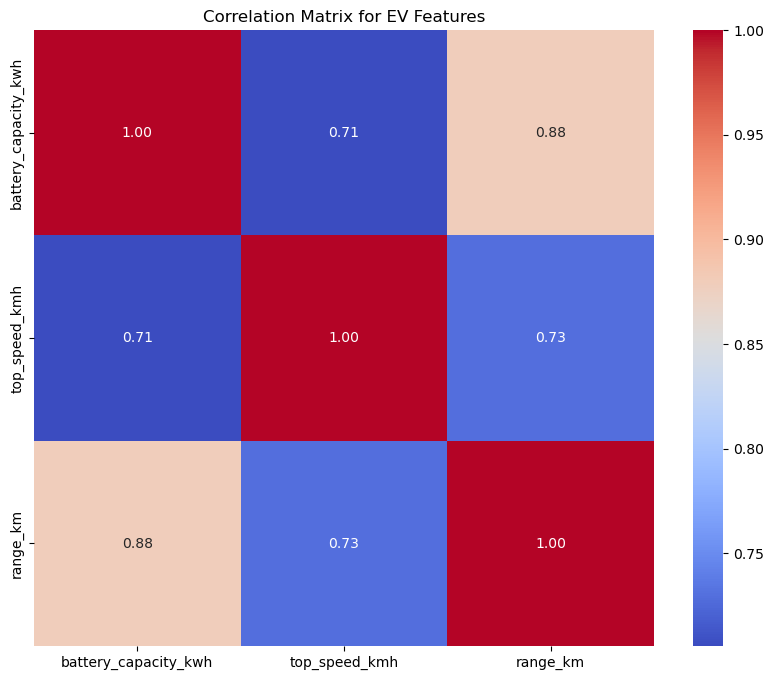

In [25]:
# 2. TRANSPARENT FEATURE SELECTION
# ---------------------------------------------------------
# We prioritize these for rural adoption. Note: If 'battery_capacity'
# or others are missing from your CSV, this script will notify you.
potential_features = ['battery_capacity_kwh', 'charge_power_kw', 'top_speed_kmh']
target = 'range_km'

# Only use features that actually exist in the CSV
features = [f for f in potential_features if f in pop.columns]
print(f"Features selected for modeling: {features}")

df = pop[features + [target]].dropna()

# Addressing feedback: Correlation Matrix for transparency
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for EV Features")
plt.show()

In [26]:
# 3. TRAIN/TEST SPLIT
# ---------------------------------------------------------
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 4. HYPERPARAMETER TUNING
# ---------------------------------------------------------
# We use GridSearchCV to find the best settings for each model
results = {}

# --- Linear Regression ---
lr_grid = GridSearchCV(LinearRegression(), {'fit_intercept': [True, False]}, cv=5)
lr_grid.fit(X_train, y_train)
results['Linear Regression'] = lr_grid

# --- Random Forest ---
rf_params = {
    'n_estimators': [100, 200, 300], # Added values
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10] # Added values
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)
results['Random Forest'] = rf_grid

# --- Gradient Boosting ---
gb_params = {
    'n_estimators': [100, 200, 300], # Added values
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7] # Added values
}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train)
results['Gradient Boosting'] = gb_grid

In [28]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, lr_preds))
print("MAE:", mean_absolute_error(y_test, lr_preds))

Linear Regression
R2: 0.7544227916294807
MAE: 38.30558987743349


In [29]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\nRandom Forest")
print("R2:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))


Random Forest
R2: 0.8027332308868822
MAE: 28.62217726014141


In [30]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

print("\nGradient Boosting")
print("R2:", r2_score(y_test, gb_preds))
print("MAE:", mean_absolute_error(y_test, gb_preds))



Gradient Boosting
R2: 0.8015514682402273
MAE: 30.979148889879824
